# Classical vs Quantum Classifiers

Minimal comparison notebook for:

- a variational quantum classifier
- a quantum kernel classifier
- a simple classical baseline

The notebook is intentionally a package client for the quantum workflows.

In [1]:
from sklearn.svm import SVC

from qml.classifiers import run_vqc
from qml.data import make_moons_dataset
from qml.metrics import accuracy_score
from qml.kernel_methods import run_quantum_kernel_classifier

## Shared dataset configuration

In [2]:
n_samples = 100
noise = 0.1
test_size = 0.25
seed = 0

dataset = make_moons_dataset(
    n_samples=n_samples,
    noise=noise,
    test_size=test_size,
    seed=seed,
)

x_train = dataset["x_train"]
x_test = dataset["x_test"]
y_train = dataset["y_train"]
y_test = dataset["y_test"]

## Variational quantum classifier

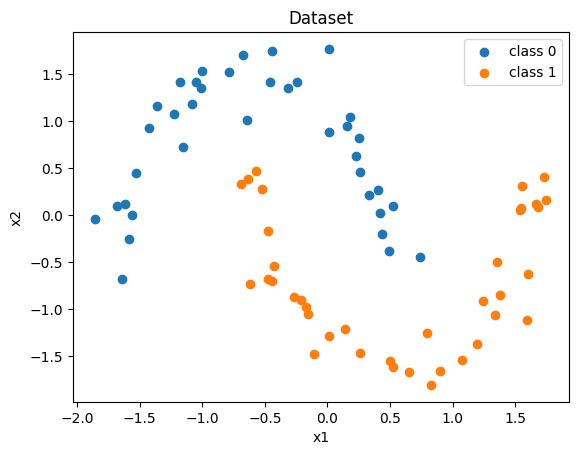

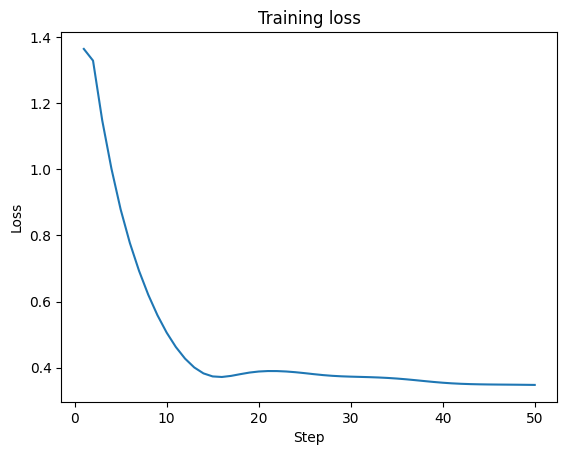

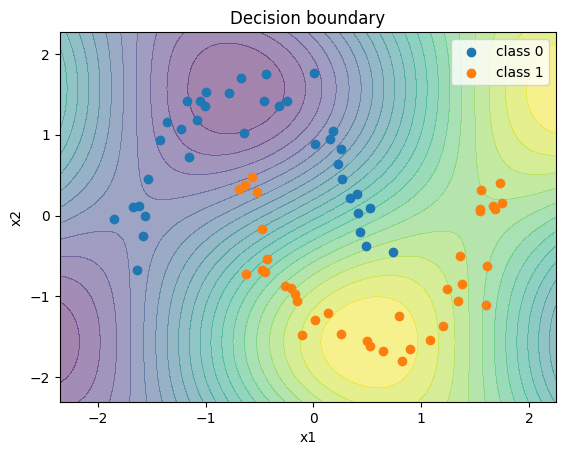

In [3]:
vqc_result = run_vqc(
    n_samples=n_samples,
    noise=noise,
    test_size=test_size,
    seed=seed,
    n_layers=2,
    steps=50,
    step_size=0.1,
    plot=True,
    save=True,
)

In [4]:
print("VQC train accuracy:", vqc_result["train_accuracy"])
print("VQC test accuracy:", vqc_result["test_accuracy"])

VQC train accuracy: 0.84
VQC test accuracy: 0.92


## Quantum kernel classifier

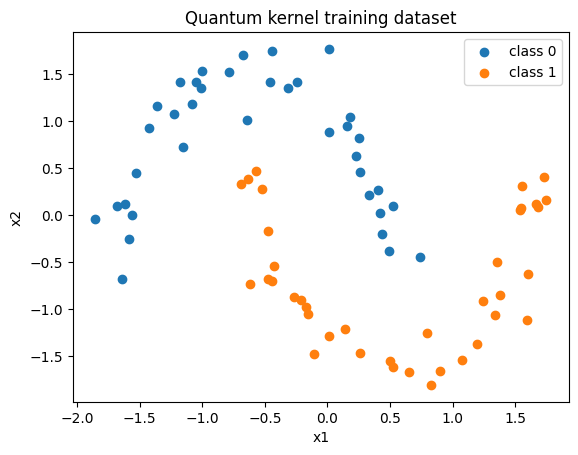

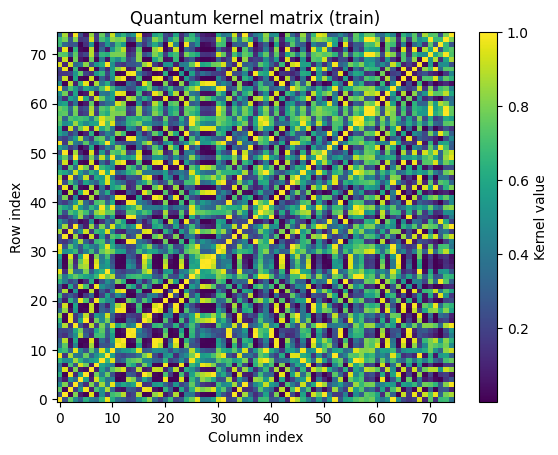

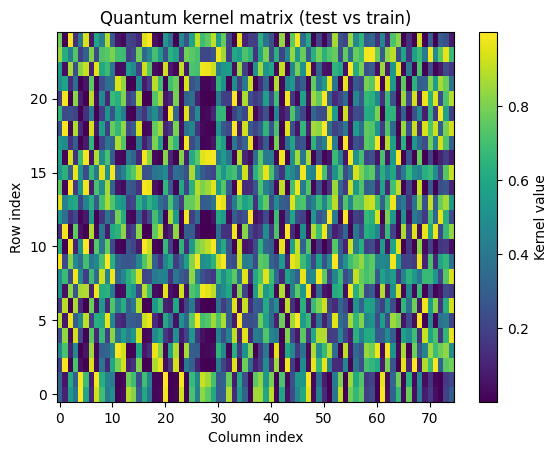

In [5]:
qk_result = run_quantum_kernel_classifier(
    n_samples=n_samples,
    noise=noise,
    test_size=test_size,
    seed=seed,
    plot=True,
    save=True,
)

In [6]:
print("Quantum kernel train accuracy:", qk_result["train_accuracy"])
print("Quantum kernel test accuracy:", qk_result["test_accuracy"])

Quantum kernel train accuracy: 0.8666666666666667
Quantum kernel test accuracy: 0.92


## Classical baseline

A simple RBF-kernel SVM is used as the classical reference model.

In [7]:
clf = SVC(kernel="rbf")
clf.fit(x_train, y_train)

y_train_pred_classical = clf.predict(x_train)
y_test_pred_classical = clf.predict(x_test)

classical_train_accuracy = accuracy_score(y_train, y_train_pred_classical)
classical_test_accuracy = accuracy_score(y_test, y_test_pred_classical)

In [8]:
print("Classical SVM train accuracy:", classical_train_accuracy)
print("Classical SVM test accuracy:", classical_test_accuracy)

Classical SVM train accuracy: 0.96
Classical SVM test accuracy: 1.0


## Summary

In [9]:
summary = {
    "VQC": {
        "train_accuracy": vqc_result["train_accuracy"],
        "test_accuracy": vqc_result["test_accuracy"],
    },
    "Quantum kernel": {
        "train_accuracy": qk_result["train_accuracy"],
        "test_accuracy": qk_result["test_accuracy"],
    },
    "Classical SVM": {
        "train_accuracy": classical_train_accuracy,
        "test_accuracy": classical_test_accuracy,
    },
}

summary

{'VQC': {'train_accuracy': 0.84, 'test_accuracy': 0.92},
 'Quantum kernel': {'train_accuracy': 0.8666666666666667,
  'test_accuracy': 0.92},
 'Classical SVM': {'train_accuracy': 0.96, 'test_accuracy': 1.0}}

## Notes

- the quantum workflows are imported from the package
- the classical baseline is kept deliberately simple
- this notebook compares outcomes, not training cost or runtime